In [5]:
import pandas as pd
import geopandas as gpd
import numpy as np

from tqdm import tqdm
from shapely import Polygon, make_valid, geometry

In [7]:
ressource_survey_path = "../../../resources/surveys/edgt_lyon"
cleaned_survey_path = "../../../results/surveys/edgt_lyon"
locations_path = "../../../resources/locations"

output_path = "../../../results/surveys/edgt_lyon/trips.geoparquet"

In [184]:
if "papermill" in locals():
    survey_path = papermill.input["survey"]
    spatial_path = papermill.input["spatial"]

    output_path = papermill.output[0]

In [185]:
# Load spatial data

gdf_housing: gpd.GeoDataFrame = gpd.read_file("%s/lyon_all_potential_housing.gpkg" % locations_path, layer="housing")
gdf_work: gpd.GeoDataFrame = gpd.read_file("%s/lyon_all_potential_work.gpkg" % locations_path, layer="work")
gdf_education: gpd.GeoDataFrame = gpd.read_file("%s/lyon_all_potential_education.gpkg" % locations_path, layer="education")
gdf_secondary: gpd.GeoDataFrame = gpd.read_file("%s/lyon_all_potential_secondary.gpkg" % locations_path, layer="secondary")

gdf_zones: gpd.GeoDataFrame = gpd.read_file("%s/EDGT_AML2015_ZF_GT.TAB" % ressource_survey_path).to_crs("EPSG:2154")

In [186]:
gdf_housing


,location_id,weight,geometry
0,home_0,1.0,POINT (848193.38 6563109.52)
1,home_1,1.0,POINT (848203.98 6563089.67)
2,home_2,1.0,POINT (848214.41 6563076.71)
3,home_3,1.0,POINT (848221.98 6562965.48)
4,home_4,0.5,POINT (848245.17 6562942.05)
...,...,...,...
1202292,home_1202292,1.0,POINT (914706.049 6455313.756)
1202293,home_1202293,1.0,POINT (844485.142 6521425.826)
1202294,home_1202294,1.0,POINT (842684.713 6518921.219)
1202295,home_1202295,1.0,POINT (843266.058 6519578.269)


In [187]:
df_households = pd.read_parquet("%s/households.parquet" % cleaned_survey_path)
df_households

,edgt_household_id,zone_id,household_id,number_of_cars,number_of_motorbikes,number_of_bicycles
0,10100184,101001,0,0,0,2
1,101001115,101001,1,1,0,1
2,1010022,101002,2,1,0,2
3,1010024,101002,3,0,0,0
4,1010025,101002,4,0,0,0
...,...,...,...,...,...,...
6610,712451647,712451,16356,1,0,0
6611,712451653,712451,16357,1,0,1
6612,712451686,712451,16358,1,0,3
6613,712451742,712451,16359,1,2,0


In [189]:


# Merge df_households with gdf_zones to get the geometries
gdf_zones["zone_id"] = gdf_zones["ZF2015_Nouveau_codage"].astype(int)



# Function to select a random point based on weight
def process_group(household_group):
    zone_id = household_group.name

    group_zone_geometry: Polygon = gdf_zones[gdf_zones["zone_id"] == zone_id]["geometry"].iloc[0]
    # Filter gdf_housing based on whether the point is within the zone geometry
    if not group_zone_geometry.is_valid:
        group_zone_geometry = make_valid(group_zone_geometry)
    
    filtered_housing: gpd.GeoDataFrame = gdf_housing[gdf_housing.within(group_zone_geometry)]
    
    assigned_housing = filtered_housing.sample(n=len(household_group), weights="weight", replace=True)
    assigned_housing = assigned_housing["geometry"].reset_index(drop=True)
    return assigned_housing

if True:
    df_households.sort_values("zone_id", inplace=True)
    df_households["geometry"] = df_households.groupby('zone_id').apply(process_group).reset_index(drop=True).values

    gdf_households = gpd.GeoDataFrame(df_households, geometry="geometry", crs="EPSG:2154")
    gdf_households.to_parquet("%s/households.geoparquet" % cleaned_survey_path)

else: 
    gdf_households = gpd.read_file("%s/households.geojson" % cleaned_survey_path, crs="EPSG:2154")


C:\Users\lebescond\AppData\Local\Temp\ipykernel_18244\3134334385.py:23: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_households["geometry"] = df_households.groupby('zone_id').apply(process_group).reset_index(drop=True).values


In [191]:
df_households[df_households["household_id"] == 16218]

,edgt_household_id,zone_id,household_id,number_of_cars,number_of_motorbikes,number_of_bicycles,geometry
6472,711015318,711015,16218,2,0,2,POINT (880325.23 6541651.2)


In [192]:
gdf_households

,edgt_household_id,zone_id,household_id,number_of_cars,number_of_motorbikes,number_of_bicycles,geometry
0,10100184,101001,0,0,0,2,POINT (841508.76 6518192.58)
1,101001115,101001,1,1,0,1,POINT (841620.3 6517497.57)
3,1010024,101002,3,0,0,0,POINT (841176.56 6517576.54)
7,10100237,101002,7,0,0,0,POINT (841384.48 6517653.09)
5,10100214,101002,5,0,0,0,POINT (841364.79 6517626.53)
...,...,...,...,...,...,...,...
6610,712451647,712451,16356,1,0,0,POINT (881555.477 6542537.227)
6598,712451106,712451,16344,2,0,4,POINT (881782.066 6543892.807)
6597,71245150,712451,16343,0,0,0,POINT (882003.46 6542524.73)
6596,71245125,712451,16342,3,2,6,POINT (880758.014 6542880.381)


In [193]:
df_persons: pd.DataFrame = pd.read_parquet("%s/persons.parquet" % cleaned_survey_path)
df_trips: pd.DataFrame = pd.read_parquet("%s/trips.parquet" % cleaned_survey_path)

In [194]:
df_trips


,household_id,person_id,trip_id,mode,euclidean_distance,travel_time,departure_time,origin_cell,destination_cell,origin_activity_type,destination_activity_type,is_valid
0,0,0,0,pt,1110,900.0,38700.0,101001,102001,home,other,True
1,0,0,1,pt,1110,900.0,42300.0,102001,101001,other,home,True
2,0,1,2,pt,2590,1200.0,30000.0,101001,104001,home,work,True
3,0,1,3,pt,2750,1500.0,63900.0,104001,101001,work,home,True
4,0,2,4,pt,2390,600.0,26880.0,101001,212003,home,education,True
...,...,...,...,...,...,...,...,...,...,...,...,...
99580,16359,36561,99580,car,3610,600.0,61200.0,712451,711006,home,leisure,True
99581,16359,36561,99581,car,3610,600.0,61800.0,711006,712451,leisure,home,True
99582,16360,36562,99582,car,770,300.0,27000.0,712451,712001,home,other,True
99583,16360,36562,99583,car,770,480.0,27420.0,712001,712451,other,work,True


In [195]:
df_trips = df_trips.merge(gdf_households[["household_id", "geometry"]], on="household_id")
df_trips.rename({
    "geometry": "household_geometry",
    "origin_cell": "origin_zone_id",
    "destination_cell": "destination_zone_id",
    "origin_activity": "origin_activity_id",
}, axis=1, inplace=True)

df_trips

,household_id,person_id,trip_id,mode,euclidean_distance,travel_time,departure_time,origin_zone_id,destination_zone_id,origin_activity_type,destination_activity_type,is_valid,household_geometry
0,0,0,0,pt,1110,900.0,38700.0,101001,102001,home,other,True,POINT (841508.76 6518192.58)
1,0,0,1,pt,1110,900.0,42300.0,102001,101001,other,home,True,POINT (841508.76 6518192.58)
2,0,1,2,pt,2590,1200.0,30000.0,101001,104001,home,work,True,POINT (841508.76 6518192.58)
3,0,1,3,pt,2750,1500.0,63900.0,104001,101001,work,home,True,POINT (841508.76 6518192.58)
4,0,2,4,pt,2390,600.0,26880.0,101001,212003,home,education,True,POINT (841508.76 6518192.58)
...,...,...,...,...,...,...,...,...,...,...,...,...,...
99580,16359,36561,99580,car,3610,600.0,61200.0,712451,711006,home,leisure,True,POINT (882015.671 6543424.981)
99581,16359,36561,99581,car,3610,600.0,61800.0,711006,712451,leisure,home,True,POINT (882015.671 6543424.981)
99582,16360,36562,99582,car,770,300.0,27000.0,712451,712001,home,other,True,POINT (880725.27 6542890.88)
99583,16360,36562,99583,car,770,480.0,27420.0,712001,712451,other,work,True,POINT (880725.27 6542890.88)


In [196]:

if False:
    df_trips = df_trips.loc[:100].copy()


# Function to select a random point based on weight
def process_trip_group(trip_group):
    zone_id = trip_group.name[0]
    activity = trip_group.name[1]

    result = pd.Series([None] * len(trip_group), name="geometry")

    group_zone = gdf_zones[(gdf_zones["zone_id"] == zone_id) & (gdf_zones["geometry"].geometry.type != 'Point')]
    if group_zone.empty:
        group_zone = gdf_zones[(gdf_zones["zone_id"] == zone_id) & (gdf_zones["geometry"].geometry.type == 'Point')]
        if group_zone.empty:
            return result
        else:
            return  pd.Series([group_zone["geometry"].iloc[0]] * len(trip_group), name="geometry")

    group_zone_geometry = group_zone["geometry"].iloc[0]

    if not group_zone_geometry.is_valid:
        group_zone_geometry = make_valid(group_zone_geometry)
    
    if activity == "home":
        return trip_group["household_geometry"].rename("geometry")
    
    weights = None

    if activity == "work":
        gdf_filtered: gpd.GeoDataFrame = gdf_work[gdf_work.within(group_zone_geometry)]
        weights = "employees"
        if gdf_filtered.empty:
            gdf_filtered = gdf_work.iloc[[gdf_work.distance(group_zone_geometry).idxmin()]]
    elif activity == "education":
        gdf_filtered: gpd.GeoDataFrame = gdf_education[gdf_education.within(group_zone_geometry)]
        if gdf_filtered.empty:
            gdf_filtered = gdf_education.iloc[[gdf_education.distance(group_zone_geometry).idxmin()]]
        weights = "weight"
    elif activity in ["leisure", "shop", "other"]:
        mask = gdf_secondary.within(group_zone_geometry)
        mask &= gdf_secondary["activity_type"] == activity
        gdf_filtered: gpd.GeoDataFrame = gdf_secondary[mask]
        if gdf_filtered.empty:
            gdf_filtered = gdf_secondary.iloc[[gdf_secondary.distance(group_zone_geometry).idxmin()]]

    if gdf_filtered.empty:
        weights=None
        gdf_filtered: gpd.GeoDataFrame = gdf_secondary[gdf_secondary.within(group_zone_geometry)]
        if gdf_filtered.empty:
            gdf_filtered = gdf_secondary.iloc[[gdf_secondary.distance(group_zone_geometry).idxmin()]]
    
    result = gdf_filtered.sample(n=len(trip_group), weights=weights, replace=True)["geometry"].reset_index(drop=True)
    return result.rename("geometry")

# NEEEED to sort first !!!
tqdm.pandas(desc="Calculating origin_geometry")
df_trips.sort_values(["origin_zone_id", "origin_activity_type"], inplace=True)
origin_geometry = df_trips.groupby(["origin_zone_id", "origin_activity_type"]).progress_apply(process_trip_group, include_groups=False).reset_index(drop=True)
df_trips["origin_geometry"] = origin_geometry.values

tqdm.pandas(desc="Calculating destination_geometry")
df_trips.sort_values(["destination_zone_id", "destination_activity_type"], inplace=True)
destination_geometry = df_trips.groupby(["destination_zone_id", "destination_activity_type"]).progress_apply(process_trip_group, include_groups=False).reset_index(drop=True)
df_trips["destination_geometry"] = destination_geometry.values

df_trips

Calculating origin_geometry:   0%|          | 9/7342 [00:00<05:02, 24.23it/s]

Calculating destination_geometry: 100%|██████████| 7277/7277 [06:21<00:00, 19.08it/s] 


,household_id,person_id,trip_id,mode,euclidean_distance,travel_time,departure_time,origin_zone_id,destination_zone_id,origin_activity_type,destination_activity_type,is_valid,household_geometry,origin_geometry,destination_geometry
80797,12383,27096,80797,walk,290,300.0,45000.0,101001,101001,leisure,education,True,POINT (836917.44 6510061.22),POINT (841168.3683546104 6516864.62812029),POINT (841683.2 6517434.1)
91,19,33,91,walk,696,720.0,31500.0,101002,101001,home,education,True,POINT (841251.48 6517663.24),POINT (841251.48 6517663.24),POINT (841607.6 6518297.5)
93,19,33,93,walk,2609,2700.0,49500.0,101002,101001,home,education,True,POINT (841251.48 6517663.24),POINT (841251.48 6517663.24),POINT (841607.6 6518297.5)
20098,3330,6305,20098,pt,5720,1800.0,30000.0,136003,101001,home,education,True,POINT (847002.052 6519993.826),POINT (847002.0515579024 6519993.825979705),POINT (841505.6435842451 6517298.579645115)
33050,5443,10716,33050,pt,4240,1800.0,26100.0,214007,101001,home,education,True,POINT (840178.88 6516881.2),POINT (840178.88 6516881.2),POINT (841505.6435842451 6517298.579645115)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1167,165,309,1167,walk,116,120.0,50400.0,999090,999090,leisure,work,True,POINT (842464.41 6518586.14),None,None
97038,15810,35271,97038,car_passenger,0,300.0,47100.0,999090,999090,leisure,work,True,POINT (869606.079 6535794.134),None,None
80721,12369,27057,80721,car,0,720.0,64800.0,999100,999100,work,home,True,POINT (836762.44 6510014.45),None,None
57935,8530,18193,57935,walk,580,600.0,51600.0,999100,999100,home,work,True,POINT (846993.159 6502333.681),None,None


In [197]:

df_trips = df_trips[(~df_trips["origin_geometry"].isna()) & (~df_trips["destination_geometry"].isna())]

In [198]:
df_trips.loc[:, "trip_geometry"] = df_trips.apply(lambda x: geometry.LineString([x["origin_geometry"], x["destination_geometry"]]), axis=1)
gdf_trips = gpd.GeoDataFrame(df_trips, geometry="trip_geometry", crs="EPSG:2154")
gdf_trips["household_geometry"] = gpd.GeoSeries(gdf_trips["household_geometry"]).to_wkt()
gdf_trips["origin_geometry"] = gpd.GeoSeries(gdf_trips["origin_geometry"]).to_wkt()
gdf_trips["destination_geometry"] = gpd.GeoSeries(gdf_trips["destination_geometry"]).to_wkt()

C:\Users\lebescond\AppData\Local\Temp\ipykernel_18244\4106265429.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_trips.loc[:, "trip_geometry"] = df_trips.apply(lambda x: geometry.LineString([x["origin_geometry"], x["destination_geometry"]]), axis=1)


In [11]:
if True:
    gdf_trips = gpd.read_file("%s/trips.geojson" % cleaned_survey_path, crs="EPSG:2154")

gdf_test = gdf_trips.copy()

gdf_test["distance_error"] = gdf_test["euclidean_distance"] - gdf_test["geometry"].length
gdf_test["distance_error"].describe()

c:\Users\lebescond\AppData\Local\miniforge3\envs\choice_model\Lib\site-packages\pyogrio\raw.py:198: RuntimeWarning: driver GeoJSON does not support open option CRS
  return ogr_read(


count    96047.000000
mean       -32.873218
std       1473.856491
min     -62416.065633
25%       -411.774573
50%        -20.524282
75%        337.584980
max      51010.000000
Name: distance_error, dtype: float64

<Axes: >

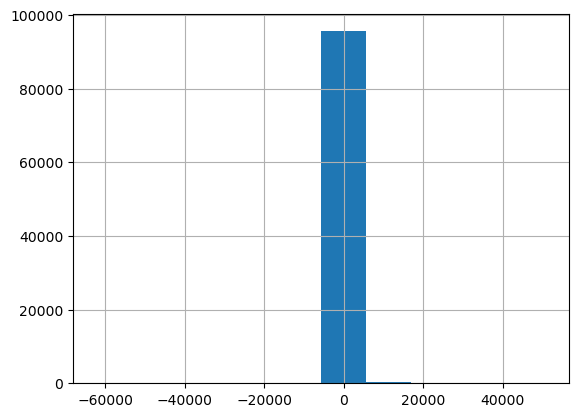

In [14]:
gdf_test["distance_error"].hist()

In [199]:
gdf_trips.to_parquet("%s/trips.geoparquet" % cleaned_survey_path)

In [200]:
gdf_trips.to_file("%s/trips.geojson" % cleaned_survey_path, driver="GeoJSON")